## Some Findings

### Are EGARCH(p,o,q) eligible?

Some interesting results:

I tried different EGARCH models. EGARCH(1,1,1),EGARCH(1,1,2),EGARCH(2,2,1),EGARCH(2,2,2) behave nicely--they converge consistently no matter what starting points I used. However, when $p\neq o$, EGARCH becomes unstable, which means that the likelihood ratio (loss function) surface formed by the model parameters is very rugged, with very large gradients, which causes gradient-based iterative optimization algorithms to fail.

I checked Nelson(1991). In this paper, he didn't allow $p\neq o$. He considered $g(\varepsilon_t)$ as a transformation of lag information:

\begin{align}
g(\varepsilon_t) = \alpha\varepsilon_t + \gamma\left[ |\varepsilon_t| - E|\varepsilon_t| \right] ,
\end{align}

and EGARCH model specification:
\begin{align}
  a_t =& \sigma_t \varepsilon_t, \\
  \ln\sigma_t^2 =& \alpha_0
  + \sum_{j=1}^p \left[\alpha_j \varepsilon_{t-j} 
  + \gamma_j(|\varepsilon_{t-j}| - E |\varepsilon_{t-j}|) \right]
  + \sum_{i=1}^q \beta_i \ln \sigma_{t-i}^2 .
\end{align}

And I checked Matlab and R packages, which don't allow $p\neq o$. (Maybe we can prove when $p\neq o$, there is no optima parameters that minizing likelihood ratio.) It seems that we need to use EGARCH with $p = o$.

1. GARCH, GJR GARCH and EGARCH(p,p,q) results seem robust as I got same parameter estimation using different starting points. 
2. EGARCH(p,o,q) estimation is volatile when $p\neq o$.
3. One potential way to deal with this issue:  Manually pick some starting points, monitoring optimization processes, getting some "good enough" points and then grid searching around these points. 
4. Extremely low standard errors were caused by in-convergent likelihood ratio. Previously I did not notice those EGARCH(2,1,1) did not converge correctlt. After fixing this problem, standard errors are not insane as before.

**Optimization Kernel**

Method SLSQP uses Sequential Least SQuares Programming to minimize a function of several variables with any combination of bounds, equality and inequality constraints. The method wraps the SLSQP Optimization subroutine originally implemented by Dieter Kraft[1]. Note that the wrapper handles infinite values in bounds by converting them into large floating values.

[1] Kraft, D. A software package for sequential quadratic programming. 1988. Tech. Rep. DFVLR-FB 88-28, DLR German Aerospace Center – Institute for Flight Mechanics, Koln, Germany.
https://en.wikipedia.org/wiki/Sequential_quadratic_programming

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from arch.univariate import ARX

In [2]:
path = os.path.abspath('E:/RA/Geert/task1.py')
dir_path = os.path.dirname(path)
os.chdir(dir_path)
excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')
sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
#quarterly and monthly aggregate CPI data (deseasonalized). The full sample is 1947-2022
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))
data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
sample_data = data_quarter[data_quarter['Year']>1969]

In [4]:
sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
sample_data['Forecasted_inflation_lag_1'] =  sample_data['Forecasted inflation'].shift(1)
sample_data = sample_data.dropna()

EGARCH(2,1,1)

$
\pi (t) =  fc(t-1) + \epsilon (t)
$

In [10]:
from arch.univariate import SkewStudent,StudentsT

In [12]:
gjr_garch221 = arch_model(y=sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=1, q=1)
gjr_garch221.distribution = StudentsT()
res = gjr_garch221.fit(cov_type='robust')
res.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 389.33435366083665
Iteration:      2,   Func. Count:     12,   Neg. LLF: 179.1745518230072
Iteration:      3,   Func. Count:     18,   Neg. LLF: 360.6568585105728
Iteration:      4,   Func. Count:     24,   Neg. LLF: 340.6381631577377
Iteration:      5,   Func. Count:     30,   Neg. LLF: 174.18655422536085
Iteration:      6,   Func. Count:     35,   Neg. LLF: 173.79131639645027
Iteration:      7,   Func. Count:     40,   Neg. LLF: 173.77974951863422
Iteration:      8,   Func. Count:     45,   Neg. LLF: 173.77793272421775
Iteration:      9,   Func. Count:     50,   Neg. LLF: 173.77792049813377
Iteration:     10,   Func. Count:     54,   Neg. LLF: 173.77792049814903
Optimization terminated successfully    (Exit mode 0)
            Current function value: 173.77792049813377
            Iterations: 10
            Function evaluations: 54
            Gradient evaluations: 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Zero Mean - GARCH Model Results                           
====================================================================================
Dep. Variable:              Inflation shock   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.005
Vol Model:                            GARCH   Log-Likelihood:               -173.778
Distribution:      Standardized Student's t   AIC:                           355.556
Method:                  Maximum Likelihood   BIC:                           368.906
                                              No. Observations:                  208
Date:                      Mon, Jun 12 2023   Df Residuals:                      208
Time:                              19:55:37   Df Model:                            0
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0855  4.104e-02      2.084  3.714e-02 [5.102e-03,  0.166]
alpha[1]       0.6721      0.187      3.594  3.252e-04   [  0.306,  1.039]
beta[1]        0.3279      0.129      2.544  1.094e-02 [7.533e-02,  0.581]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.0615      1.141      3.560  3.709e-04 [  1.825,  6.298]
========================================================================

Covariance estimator: robust
"""


$\ln\Gamma\left(\frac{\nu+1}{2}\right)
            -\ln\Gamma\left(\frac{\nu}{2}\right)
            -\frac{1}{2}\ln(\pi\left(\nu-2\right)\sigma^{2})
            -\frac{\nu+1}{2}\ln(1+x^{2}/(\sigma^{2}(\nu-2)))
$

In [31]:
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', p=2, o=2, q=1,dist='normal',lags=[1,2]).fit(disp='off',cov_type='robust')
gjr_garch21.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        AR-X - GJR-GARCH Model Results                        
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.439
Mean Model:                      AR-X   Adj. R-squared:                  0.431
Vol Model:                  GJR-GARCH   Log-Likelihood:               -170.111
Distribution:                  Normal   AIC:                           360.221
Method:            Maximum Likelihood   BIC:                           393.500
                                        No. Observations:                  206
Date:                Mon, Jun 05 2023   Df Residuals:                      202
Time:                        22:25:20   Df Model:                            4
                                      Mean Model                                     
=====================================================================================
                           coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------
Const                    0.0922  9.084e-02      1.015      0.310 [-8.587e-02,  0.270]
Inflation[1]             0.1279      0.124      1.031      0.302    [ -0.115,  0.371]
Inflation[2]             0.0438      0.134      0.327      0.744    [ -0.219,  0.306]
Forecasted inflation     0.8121      0.225      3.602  3.163e-04    [  0.370,  1.254]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1382  4.918e-02      2.810  4.948e-03  [4.182e-02,  0.235]
alpha[1]       0.2728      0.173      1.573      0.116 [-6.712e-02,  0.613]
alpha[2]       0.8232      0.415      1.983  4.733e-02  [9.695e-03,  1.637]
gamma[1]      -0.1178      0.240     -0.490      0.624    [ -0.589,  0.353]
gamma[2]      -0.8232      0.392     -2.103  3.550e-02 [ -1.591,-5.585e-02]
beta[1]        0.1007      0.144      0.700      0.484    [ -0.181,  0.383]
===========================================================================

Covariance estimator: robust
"""

<Axes: >

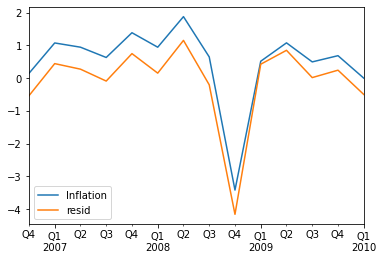

In [63]:
df = pd.DataFrame(gjr_garch21.resid)
df.iloc[143:157,:]
pd.concat([ sample_data['Inflation'][143:157],df.iloc[143:157,:]],axis=1).plot()

<Axes: >

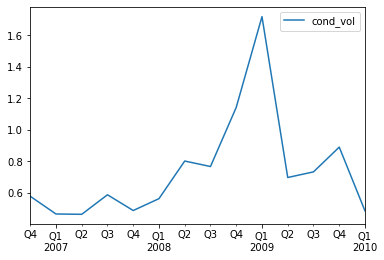

In [50]:
cv = pd.DataFrame(gjr_garch21.conditional_volatility)
cv.iloc[143:157,:].plot(legend = "Residuals Square")

<Axes: >

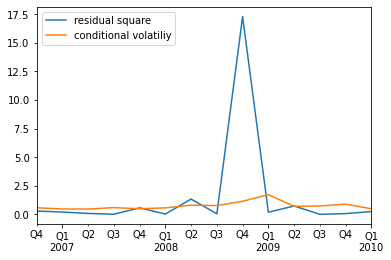

In [58]:
pd.concat([(df.iloc[143:157,:]**2), cv.iloc[143:157,:]], axis=1).rename(columns={'resid':'residual square','cond_vol':'conditional volatiliy'}).plot()

Residual Square VS Conditional Volatility


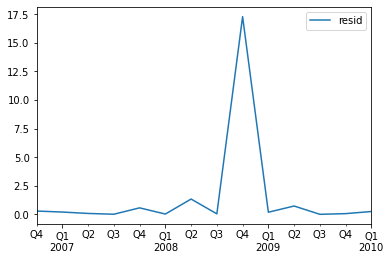

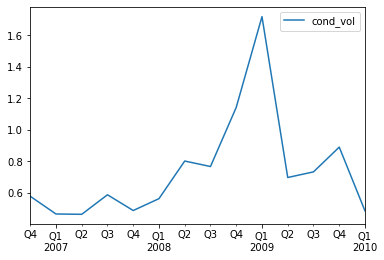

In [51]:
(df.iloc[143:157,:]**2).plot(legend = "Residuals Square")
cv.iloc[143:157,:].plot(legend = "Conditional Volatiliy")
print('Residual Square VS Conditional Volatility')

<Axes: >

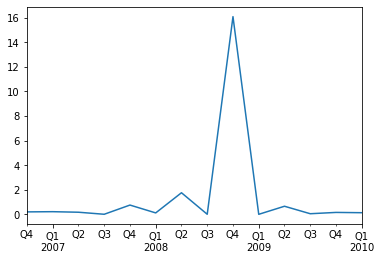

In [44]:
(sample_data['Inflation shock'][143:157]**2).plot()

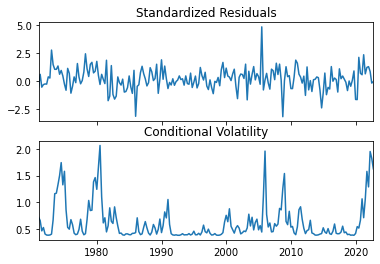

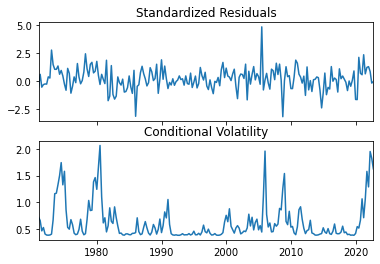

In [15]:
gjr_garch221.plot()

$
\pi (t) = c +\rho \pi (t-1)   + \phi fc(t-1) + \epsilon (t)
$

In [63]:
egarch211 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', vol='EGARCH',p=2, o=1, q=1,dist='normal',lags=[1]).fit(cov_type='robust')
egarch211.summary()

Iteration:      1,   Func. Count:     10,   Neg. LLF: 1363536868876.9282
Iteration:      2,   Func. Count:     23,   Neg. LLF: 122061515824.94955
Iteration:      3,   Func. Count:     35,   Neg. LLF: 59476015821.324814
Iteration:      4,   Func. Count:     47,   Neg. LLF: 21303115553.883087
Iteration:      5,   Func. Count:     59,   Neg. LLF: 1492519814.4086506
Iteration:      6,   Func. Count:     70,   Neg. LLF: 326113371.4420381
Iteration:      7,   Func. Count:     81,   Neg. LLF: 2853000147.0190287
Iteration:      8,   Func. Count:     93,   Neg. LLF: 313.44652137693333
Iteration:      9,   Func. Count:    103,   Neg. LLF: 161826166.00306547
Iteration:     10,   Func. Count:    114,   Neg. LLF: 203.4649254143922
Iteration:     11,   Func. Count:    124,   Neg. LLF: 177.17557567663226
Iteration:     12,   Func. Count:    134,   Neg. LLF: 175.12015388510255
Iteration:     13,   Func. Count:    143,   Neg. LLF: 175.10160186305714
Iteration:     14,   Func. Count:    152,   Neg. LLF:

<class 'statsmodels.iolib.summary.Summary'>
"""
                         AR-X - EGARCH Model Results                          
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.454
Mean Model:                      AR-X   Adj. R-squared:                  0.448
Vol Model:                     EGARCH   Log-Likelihood:               -175.094
Distribution:                  Normal   AIC:                           366.187
Method:            Maximum Likelihood   BIC:                           392.849
                                        No. Observations:                  207
Date:                Sun, Jun 04 2023   Df Residuals:                      204
Time:                        23:29:19   Df Model:                            3
                                    Mean Model                                    
==================================================================================
                           coef    std err          t      P>|t|  95.0% Conf. Int.
----------------------------------------------------------------------------------
Const                    0.0566      0.231      0.245      0.806 [ -0.396,  0.510]
Inflation[1]             0.3254      0.284      1.145      0.252 [ -0.232,  0.882]
Forecasted inflation     0.7159      0.139      5.158  2.494e-07 [  0.444,  0.988]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega         -0.0673      0.244     -0.276      0.783    [ -0.545,  0.411]
alpha[1]       0.4878      0.295      1.654  9.803e-02 [-9.007e-02,  1.066]
alpha[2]      -0.3635      0.252     -1.441      0.150    [ -0.858,  0.131]
gamma[1]       0.2543      0.187      1.363      0.173    [ -0.111,  0.620]
beta[1]        0.9314      0.223      4.169  3.056e-05    [  0.494,  1.369]
===========================================================================

Covariance estimator: robust
"""

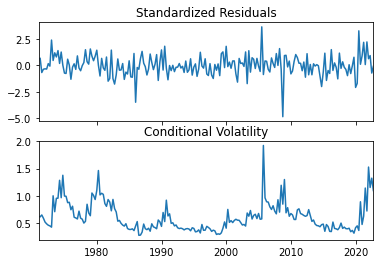

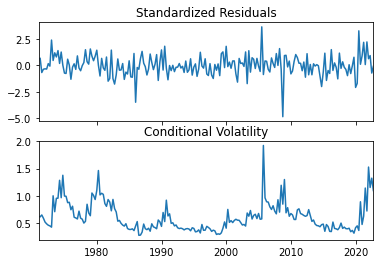

In [64]:
egarch211.plot()

Residual Square VS Conditional Volatility


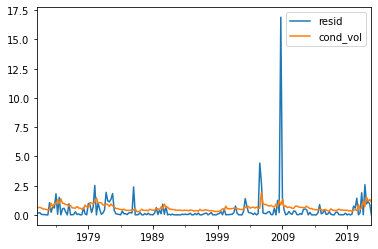

In [66]:
(egarch211.resid**2).plot(legend = "Residuals Square")
egarch211.conditional_volatility.plot(legend = "Conditional Volatiliy")
print('Residual Square VS Conditional Volatility')

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi fc(t-1) + \epsilon (t)
$

In [98]:
egarch221 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', vol='EGARCH',p=2, o=2, q=1,dist='normal',lags=[1,2]).fit(cov_type='robust')
egarch221.summary()

Iteration:      1,   Func. Count:     12,   Neg. LLF: 2544242899.5374618
Iteration:      2,   Func. Count:     27,   Neg. LLF: 1686055983351.86
Iteration:      3,   Func. Count:     42,   Neg. LLF: 6570654232.656852
Iteration:      4,   Func. Count:     55,   Neg. LLF: 65310553188.09985
Iteration:      5,   Func. Count:     69,   Neg. LLF: 1603157875.912602
Iteration:      6,   Func. Count:     82,   Neg. LLF: 2208759443.401947
Iteration:      7,   Func. Count:     95,   Neg. LLF: 2120361944.0620723
Iteration:      8,   Func. Count:    108,   Neg. LLF: 426.27570512230807
Iteration:      9,   Func. Count:    121,   Neg. LLF: 375.8949113623397
Iteration:     10,   Func. Count:    133,   Neg. LLF: 49431694.85309681
Iteration:     11,   Func. Count:    146,   Neg. LLF: 171.3180884938929
Iteration:     12,   Func. Count:    157,   Neg. LLF: 170.94586822539208
Iteration:     13,   Func. Count:    168,   Neg. LLF: 170.86469935630578
Iteration:     14,   Func. Count:    179,   Neg. LLF: 170.83

<class 'statsmodels.iolib.summary.Summary'>
"""
                         AR-X - EGARCH Model Results                          
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.438
Mean Model:                      AR-X   Adj. R-squared:                  0.430
Vol Model:                     EGARCH   Log-Likelihood:               -170.807
Distribution:                  Normal   AIC:                           361.614
Method:            Maximum Likelihood   BIC:                           394.892
                                        No. Observations:                  206
Date:                Sun, Jun 04 2023   Df Residuals:                      202
Time:                        23:45:00   Df Model:                            4
                                      Mean Model                                     
=====================================================================================
                           coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------
Const                    0.1024  6.778e-02      1.510      0.131 [-3.047e-02,  0.235]
Inflation[1]             0.1946      0.181      1.078      0.281    [ -0.159,  0.549]
Inflation[2]         2.9676e-03      0.135  2.200e-02      0.982    [ -0.261,  0.267]
Forecasted inflation     0.7351      0.254      2.894  3.804e-03    [  0.237,  1.233]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega         -0.3728      0.174     -2.141  3.224e-02 [ -0.714,-3.159e-02]
alpha[1]       0.4763      0.285      1.672  9.448e-02 [-8.197e-02,  1.035]
alpha[2]      -0.0103      0.400 -2.583e-02      0.979    [ -0.795,  0.774]
gamma[1]       0.0595      0.149      0.400      0.689    [ -0.232,  0.351]
gamma[2]       0.3756      0.148      2.546  1.090e-02  [8.644e-02,  0.665]
beta[1]        0.6808      0.130      5.234  1.659e-07    [  0.426,  0.936]
===========================================================================

Covariance estimator: robust
"""

In [121]:
param221 = list(egarch221.params)
param221.pop(-2)
starting_values = 0.3*np.array(param111).reshape(1,9) 

options = {'maxiter': 500, }
egarch211 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', vol='EGARCH',p=2, o=1, q=1,dist='normal',lags=[1,2]).fit(cov_type='robust',starting_values=starting_values,options=options)
egarch211.summary()
#egarch212 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', vol='EGARCH',p=2, o=1, q=1,dist='normal',lags=[1,2]).fit(starting_values=egarch212.params,cov_type='robust')

Iteration:      1,   Func. Count:     11,   Neg. LLF: 12845450451634.375
Iteration:      2,   Func. Count:     24,   Neg. LLF: 14803680014.193428
Iteration:      3,   Func. Count:     36,   Neg. LLF: 258281885286.32678
Iteration:      4,   Func. Count:     49,   Neg. LLF: 212044.6497032905
Iteration:      5,   Func. Count:     61,   Neg. LLF: 287153663.1484544
Iteration:      6,   Func. Count:     73,   Neg. LLF: 1350634109.9416459
Iteration:      7,   Func. Count:     85,   Neg. LLF: 1138132244.243822
Iteration:      8,   Func. Count:     97,   Neg. LLF: 2015524091.819859
Iteration:      9,   Func. Count:    109,   Neg. LLF: 151842556.64753488
Iteration:     10,   Func. Count:    121,   Neg. LLF: 168417561.5987526
Iteration:     11,   Func. Count:    132,   Neg. LLF: 683.0181743344511
Iteration:     12,   Func. Count:    143,   Neg. LLF: 340399063.9194508
Iteration:     13,   Func. Count:    155,   Neg. LLF: 188.45477714063992
Iteration:     14,   Func. Count:    166,   Neg. LLF: 5266

<class 'statsmodels.iolib.summary.Summary'>
"""
                         AR-X - EGARCH Model Results                          
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.438
Mean Model:                      AR-X   Adj. R-squared:                  0.430
Vol Model:                     EGARCH   Log-Likelihood:               -178.411
Distribution:                  Normal   AIC:                           374.822
Method:            Maximum Likelihood   BIC:                           404.773
                                        No. Observations:                  206
Date:                Sun, Jun 04 2023   Df Residuals:                      202
Time:                        23:51:00   Df Model:                            4
                                    Mean Model                                    
==================================================================================
                           coef    std err          t      P>|t|  95.0% Conf. Int.
----------------------------------------------------------------------------------
Const                    0.1043  2.813e-04    370.600      0.000 [  0.104,  0.105]
Inflation[1]             0.3699  1.424e-04   2597.540      0.000 [  0.370,  0.370]
Inflation[2]             0.2243  7.257e-04    309.163      0.000 [  0.223,  0.226]
Forecasted inflation     0.3069  4.355e-04    704.638      0.000 [  0.306,  0.308]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega         -0.9929      0.268     -3.702  2.142e-04 [ -1.519, -0.467]
alpha[1]       0.8661      0.290      2.989  2.798e-03 [  0.298,  1.434]
alpha[2]       0.6808      0.285      2.390  1.687e-02 [  0.122,  1.239]
gamma[1]      -0.2317      0.178     -1.302      0.193 [ -0.580,  0.117]
beta[1]    1.3492e-17      0.241  5.588e-17      1.000 [ -0.473,  0.473]
========================================================================

Covariance estimator: robust
"""

Standard errors of mean model are still insane. 

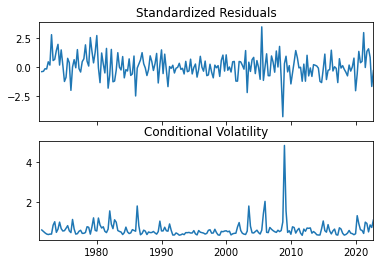

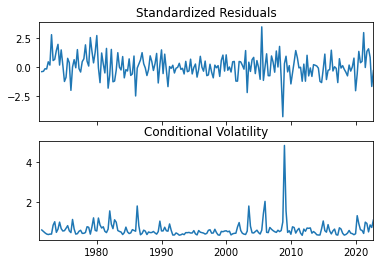

In [111]:
egarch211.plot()

Residual Square VS Conditional Volatility


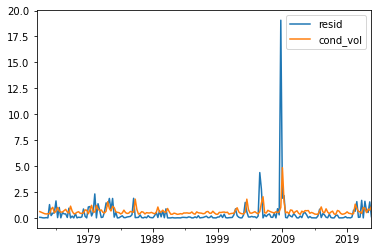

In [112]:
(egarch211.resid**2).plot(legend = "Residuals Square")
egarch211.conditional_volatility.plot(legend = "Conditional Volatiliy")
print('Residual Square VS Conditional Volatility')

### $
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi_1 fc(t-1) + \phi_2 fc(t-2) + \epsilon (t)
$

1. Starting from EGARCH(1,0,1)

In [45]:
egarch101 = arch_model(y=sample_data['Inflation'],x=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']], mean='ARX', vol='EGARCH',p=1, o=0, q=1,dist='normal',lags=[1,2]).fit(cov_type='robust',options=options)
egarch101.summary()

Iteration:      1,   Func. Count:     10,   Neg. LLF: 4767669176.807107
Iteration:      2,   Func. Count:     23,   Neg. LLF: 58404962.33952978
Iteration:      3,   Func. Count:     35,   Neg. LLF: 2607444229.0199356
Iteration:      4,   Func. Count:     47,   Neg. LLF: 24960.939039196524
Iteration:      5,   Func. Count:     58,   Neg. LLF: 324.2964220173301
Iteration:      6,   Func. Count:     68,   Neg. LLF: 234.64152226785663
Iteration:      7,   Func. Count:     78,   Neg. LLF: 248.06408235343446
Iteration:      8,   Func. Count:     89,   Neg. LLF: 237.66487247773009
Iteration:      9,   Func. Count:     99,   Neg. LLF: 183.674386775737
Iteration:     10,   Func. Count:    109,   Neg. LLF: 183.39354394051247
Iteration:     11,   Func. Count:    118,   Neg. LLF: 183.2738805725736
Iteration:     12,   Func. Count:    127,   Neg. LLF: 183.3107888667243
Iteration:     13,   Func. Count:    137,   Neg. LLF: 183.20619738036112
Iteration:     14,   Func. Count:    146,   Neg. LLF: 183.

<class 'statsmodels.iolib.summary.Summary'>
"""
                         AR-X - EGARCH Model Results                          
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.447
Mean Model:                      AR-X   Adj. R-squared:                  0.436
Vol Model:                     EGARCH   Log-Likelihood:               -183.205
Distribution:                  Normal   AIC:                           382.410
Method:            Maximum Likelihood   BIC:                           409.033
                                        No. Observations:                  206
Date:                Sun, Jun 04 2023   Df Residuals:                      201
Time:                        23:04:25   Df Model:                            5
                                         Mean Model                                        
===========================================================================================
                                 coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------------
Const                          0.0954  7.992e-02      1.193      0.233 [-6.127e-02,  0.252]
Inflation[1]                   0.3629      0.121      3.009  2.617e-03    [  0.127,  0.599]
Inflation[2]                   0.1221      0.125      0.973      0.330    [ -0.124,  0.368]
Forecasted inflation           0.3481      0.444      0.784      0.433    [ -0.522,  1.219]
Forecasted_inflation_lag_1     0.0799      0.320      0.250      0.803    [ -0.547,  0.707]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega         -0.2499      0.174     -1.435      0.151 [ -0.591,9.148e-02]
alpha[1]       0.8186      0.359      2.279  2.265e-02   [  0.115,  1.523]
beta[1]        0.6947      0.117      5.949  2.705e-09   [  0.466,  0.924]
==========================================================================

Covariance estimator: robust
"""

2. EGARCH(1,0,1) converges reasonably. Then use its parameters to train EGARCH(1,1,1)

In [48]:
param101 = list(egarch101.params)
param101.insert(7, 0.001)
starting_values = 0.5*np.array(param101).reshape(1,9)  # Example values
egarch111 = arch_model(y=sample_data['Inflation'],x=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']], mean='ARX', vol='EGARCH',p=1, o=1, q=1,dist='normal',lags=[1,2]).fit(update_freq=1,starting_values=starting_values)
egarch111.summary()

Iteration:      1,   Func. Count:     11,   Neg. LLF: 11909651217.677017
Iteration:      2,   Func. Count:     25,   Neg. LLF: 4667519453.465842
Iteration:      3,   Func. Count:     37,   Neg. LLF: 836398640.7216948
Iteration:      4,   Func. Count:     49,   Neg. LLF: 463699.12489403057
Iteration:      5,   Func. Count:     61,   Neg. LLF: 1305110184.0943375
Iteration:      6,   Func. Count:     73,   Neg. LLF: 505730175.81896645
Iteration:      7,   Func. Count:     85,   Neg. LLF: 591.2907878827641
Iteration:      8,   Func. Count:     96,   Neg. LLF: 788935577.7026745
Iteration:      9,   Func. Count:    108,   Neg. LLF: 19576699.761659224
Iteration:     10,   Func. Count:    119,   Neg. LLF: 341.1867533419734
Iteration:     11,   Func. Count:    131,   Neg. LLF: 202.33743252677567
Iteration:     12,   Func. Count:    142,   Neg. LLF: 182.44351383101628
Iteration:     13,   Func. Count:    153,   Neg. LLF: 178.8824236401394
Iteration:     14,   Func. Count:    163,   Neg. LLF: 177

<class 'statsmodels.iolib.summary.Summary'>
"""
                         AR-X - EGARCH Model Results                          
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.450
Mean Model:                      AR-X   Adj. R-squared:                  0.439
Vol Model:                     EGARCH   Log-Likelihood:               -176.276
Distribution:                  Normal   AIC:                           370.551
Method:            Maximum Likelihood   BIC:                           400.502
                                        No. Observations:                  206
Date:                Sun, Jun 04 2023   Df Residuals:                      201
Time:                        23:04:43   Df Model:                            5
                                         Mean Model                                         
============================================================================================
                                 coef    std err          t      P>|t|      95.0% Conf. Int.
--------------------------------------------------------------------------------------------
Const                          0.0232  4.066e-03      5.715  1.095e-08 [1.527e-02,3.121e-02]
Inflation[1]                   0.2148  4.369e-03     49.156      0.000     [  0.206,  0.223]
Inflation[2]                   0.0185  3.407e-03      5.438  5.381e-08 [1.185e-02,2.520e-02]
Forecasted inflation           0.6046  2.456e-03    246.208      0.000     [  0.600,  0.609]
Forecasted_inflation_lag_1     0.2193  2.572e-03     85.272      0.000     [  0.214,  0.224]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega         -0.0821      0.105     -0.784      0.433   [ -0.287,  0.123]
alpha[1]       0.2390      0.264      0.906      0.365   [ -0.278,  0.756]
gamma[1]       0.2239  8.637e-02      2.592  9.548e-03 [5.457e-02,  0.393]
beta[1]        0.9146  9.718e-02      9.412  4.884e-21   [  0.724,  1.105]
==========================================================================

Covariance estimator: robust
"""

EGARCH(1,1,1) converges reasonably. Then use its parameters to train EGARCH(2,1,1)

Below estimation is a potential optima.

In [53]:
param111 = list(egarch111.params)
param111.insert(7, 0.001)
starting_values = np.array(param111).reshape(1,10)  # Example values
egarch211 = arch_model(y=sample_data['Inflation'],x=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']], mean='ARX', vol='EGARCH',p=2, o=1, q=1,dist='normal',lags=[1,2]).fit(update_freq=1,starting_values=starting_values,options = {'maxiter':500})
egarch211.summary()

Iteration:      1,   Func. Count:     12,   Neg. LLF: 1013143652.1829851
Iteration:      2,   Func. Count:     26,   Neg. LLF: 468398880598.46936
Iteration:      3,   Func. Count:     41,   Neg. LLF: 48301716624.19513
Iteration:      4,   Func. Count:     55,   Neg. LLF: 6753314511.716436
Iteration:      5,   Func. Count:     69,   Neg. LLF: 5808622161.430824
Iteration:      6,   Func. Count:     83,   Neg. LLF: 8494567939.247814
Iteration:      7,   Func. Count:     97,   Neg. LLF: 365.3302897112155
Iteration:      8,   Func. Count:    110,   Neg. LLF: 189.3497789428482
Iteration:      9,   Func. Count:    122,   Neg. LLF: 190.86968404146478
Iteration:     10,   Func. Count:    134,   Neg. LLF: 182.19512940501573
Iteration:     11,   Func. Count:    146,   Neg. LLF: 603.701688059499
Iteration:     12,   Func. Count:    158,   Neg. LLF: 828.6702651190797
Iteration:     13,   Func. Count:    170,   Neg. LLF: 1035.5249063845129
Iteration:     14,   Func. Count:    182,   Neg. LLF: 1181.8

Iteration:    129,   Func. Count: 1.78e+03,   Neg. LLF: 34529051.81361968
Iteration:    130,   Func. Count: 1.79e+03,   Neg. LLF: 176.17669353745094
Iteration:    131,   Func. Count: 1.8e+03,   Neg. LLF: 175.96331344375125
Iteration:    132,   Func. Count: 1.82e+03,   Neg. LLF: 175.81406023909187
Iteration:    133,   Func. Count: 1.83e+03,   Neg. LLF: 175.66455901749245
Iteration:    134,   Func. Count: 1.84e+03,   Neg. LLF: 175.5469327960815
Iteration:    135,   Func. Count: 1.85e+03,   Neg. LLF: 175.38085535499872
Iteration:    136,   Func. Count: 1.86e+03,   Neg. LLF: 175.22172244280856
Iteration:    137,   Func. Count: 1.87e+03,   Neg. LLF: 176.17802540138962
Iteration:    138,   Func. Count: 1.88e+03,   Neg. LLF: 175.3169329952862
Iteration:    139,   Func. Count: 1.9e+03,   Neg. LLF: 174.80740938509797
Iteration:    140,   Func. Count: 1.91e+03,   Neg. LLF: 174.63839745393486
Iteration:    141,   Func. Count: 1.92e+03,   Neg. LLF: 207.64158946280094
Iteration:    142,   Func. Cou

<class 'statsmodels.iolib.summary.Summary'>
"""
                         AR-X - EGARCH Model Results                          
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.450
Mean Model:                      AR-X   Adj. R-squared:                  0.439
Vol Model:                     EGARCH   Log-Likelihood:               -175.268
Distribution:                  Normal   AIC:                           370.535
Method:            Maximum Likelihood   BIC:                           403.814
                                        No. Observations:                  206
Date:                Sun, Jun 04 2023   Df Residuals:                      201
Time:                        23:19:09   Df Model:                            5
                                         Mean Model                                        
===========================================================================================
                                 coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------------
Const                         -0.0138  8.568e-02     -0.161      0.872    [ -0.182,  0.154]
Inflation[1]                   0.3645      0.154      2.368  1.786e-02  [6.286e-02,  0.666]
Inflation[2]                   0.0659  8.195e-02      0.804      0.422 [-9.475e-02,  0.226]
Forecasted inflation           0.1432      0.647      0.221      0.825    [ -1.126,  1.412]
Forecasted_inflation_lag_1     0.4804      0.692      0.694      0.488    [ -0.876,  1.837]
                               Volatility Model                               
==============================================================================
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
omega         -0.0486  1.507e-02     -3.228  1.247e-03 [-7.816e-02,-1.910e-02]
alpha[1]       0.3852      0.138      2.797  5.160e-03       [  0.115,  0.655]
alpha[2]      -0.4574      0.149     -3.077  2.093e-03       [ -0.749, -0.166]
gamma[1]       0.2207      0.218      1.012      0.311       [ -0.207,  0.648]
beta[1]        0.9813  1.836e-02     53.435      0.000       [  0.945,  1.017]
==============================================================================

Covariance estimator: robust
"""

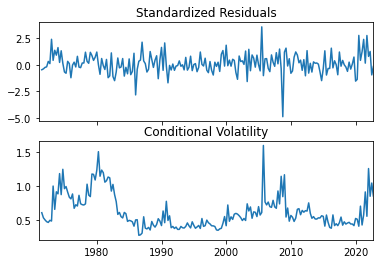

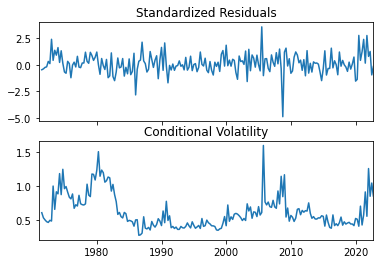

In [54]:
egarch211.plot()

Residual Square VS Conditional Volatility


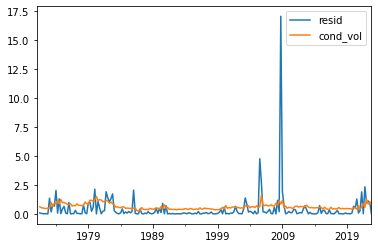

In [61]:
(egarch211.resid**2).plot(legend = "Residuals Square")
egarch211.conditional_volatility.plot(legend = "Conditional Volatiliy")
print('Residual Square VS Conditional Volatility')

When the number of parameters increase, EGARCH(2,1,1) becomes harder to converge. For the first two mean models, EGARCH(2.1,1) is feasible. However, for the last two mean model, I tried some starting values which are 10%/20%/30%/50%/100% of its value from each parameter obtained in the simpler models. Indeed, we can get an optima. But should we use EGARCH(p,o,q) that $p \neq o$?